In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

Original Data Shape: (56, 892)
t-SNE transformed shape: (56, 3)
t-SNE Component 1: 0.3326 (33.26% of total variance)
t-SNE Component 2: 0.2952 (29.52% of total variance)
t-SNE Component 3: 0.3722 (37.22% of total variance)


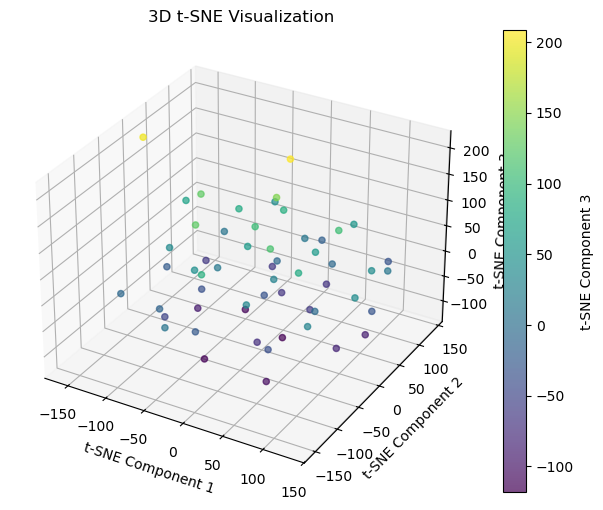

In [3]:
# Load dataset
df = pd.read_csv("size_trials4.csv", header=None)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Original Data Shape:", X_scaled.shape)

# Apply t-SNE over all components
tsne = TSNE(n_components=3, perplexity=10, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE transformed shape:", X_tsne.shape)

# Print contribution of each t-SNE component
variance = X_tsne.var(axis=0)
total_variance = variance.sum()
explained_variance_ratio = variance / total_variance

for i, ratio in enumerate(explained_variance_ratio):
   print(f"t-SNE Component {i+1}: {ratio:.4f} ({ratio*100:.2f}% of total variance)")

# Plot t-SNE results in 3D space
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=X_tsne[:, 2], cmap='viridis', alpha=0.7)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")
ax.set_title("3D t-SNE Visualization")
plt.colorbar(sc, label="t-SNE Component 3")
plt.show()

### K means after t-SNE in 3D

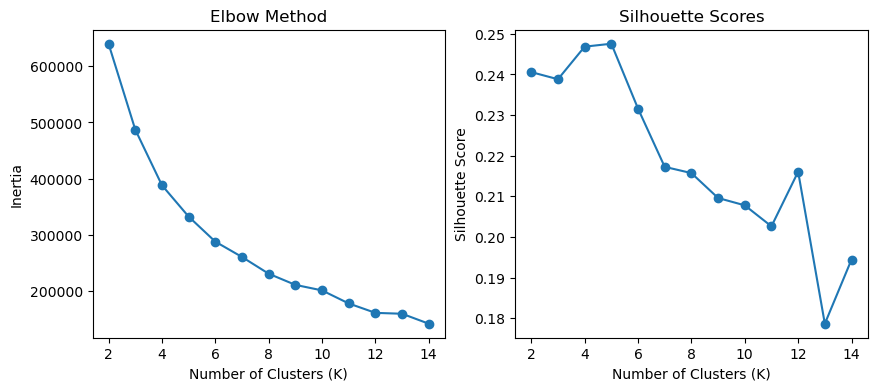

In [4]:
# Find optimal K using the Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 15)  # Test clusters from 2 to 14

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_tsne)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_tsne, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

t-SNE transformed shape: (56, 3)


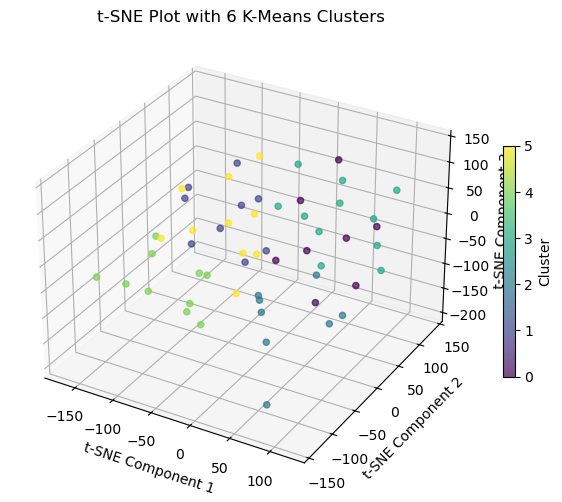

In [5]:
# Apply t-SNE to reduce the dimensionality to 3D
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE transformed shape:", X_tsne.shape)

# Apply K-Means clustering on the t-SNE results
optimal_k = 6  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_tsne)

# Plot t-SNE results with clusters in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=df['Cluster'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")
ax.set_title(f"t-SNE Plot with {optimal_k} K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()


### tSNE Component Reduction Labeled by Size in 3D

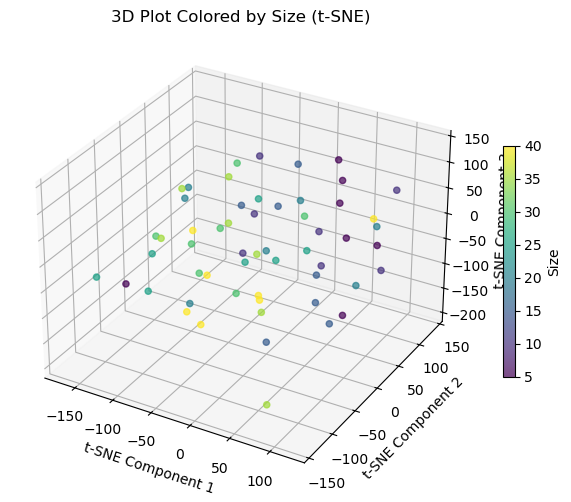

In [6]:
# 3D Plot of clusters colored by t-SNE components
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

Sz = []
for i in range(56):
    Sz.append(((i%8)*5)+5)

df['Size'] = Sz


# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1, depthshade=False)

# Labels and title
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")
ax.set_title("3D Plot Colored by Size (t-SNE)")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Size")

plt.show()


### K means after t-SNE in 2D

t-SNE transformed shape: (56, 2)


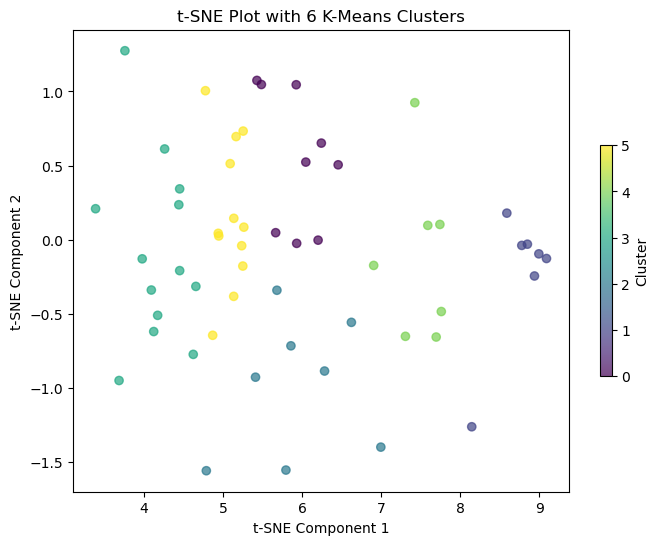

In [7]:
# Apply t-SNE to reduce the dimensionality to 2D (or 3D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE transformed shape:", X_tsne.shape)

# Apply K-Means clustering on the t-SNE results
optimal_k = 6  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_tsne)

# Plot t-SNE results with clusters
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_title(f"t-SNE Plot with {optimal_k} K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()

### tSNE Component Reduction Labeled by Size in 2D

t-SNE transformed shape: (56, 2)


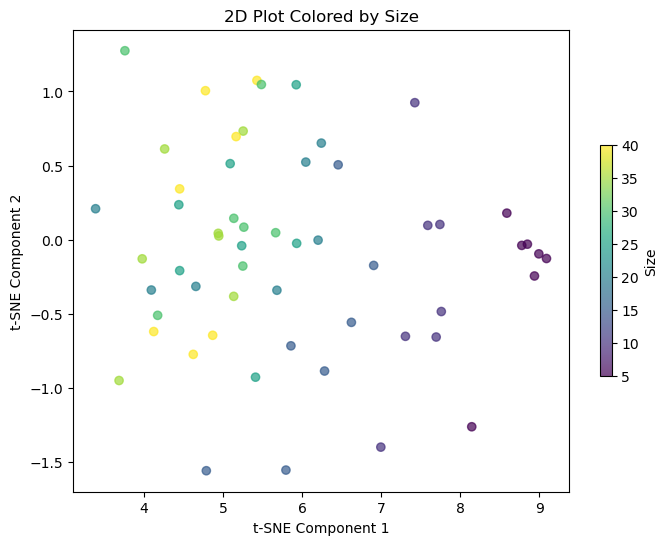

In [8]:
# Apply t-SNE to reduce the dimensionality to 2D (or 3D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE transformed shape:", X_tsne.shape)

# Apply K-Means clustering on the t-SNE results
optimal_k = 6  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=2)
df['Cluster'] = kmeans.fit_predict(X_tsne)

# Plot t-SNE results with clusters
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['Size'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_title("2D Plot Colored by Size")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Size")

plt.show()